In [194]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
SAVE_DIR = Path("/content/drive/MyDrive/semantic-drift/on_demand_contexts")

df = pd.read_csv(SAVE_DIR / "ranked_drift_top100.csv")

print(df.head())

        word  drift_score  cosine_similarity  news_contexts  reddit_contexts  \
0   sitewide     0.659313           0.340687            100              100   
1     merica     0.528275           0.471725            100              100   
2    recieve     0.517527           0.482473            100              100   
3  inbetween     0.495981           0.504019            100              100   
4     pecker     0.434871           0.565129            100              100   

   first_reddit_year  latest_reddit_year  \
0               2015                2015   
1               2015                2015   
2               2015                2015   
3               2015                2015   
4               2015                2015   

                                        old_examples  \
0  ['How is this any different than a sitewide fi...   
1  ['One recent program was devoted to wetlands, ...   
2  ['They are accused of separate murders and cou...   
3  ["If you are older you have

In [180]:
import ast
import re

bad_words = {
    "recieve", "inbetween", "pecker",
    "fisting", "whoring", "ejaculating"
}

known_entities = {
    "majora", "elden", "zelda", "pokemon", "minecraft",
    "reddit", "youtube", "google", "america"
}

def safe_list(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

def is_probably_proper_noun(word, row):
    word_l = str(word).lower()

    if word_l in known_entities:
        return True

    examples = safe_list(row["old_examples"]) + safe_list(row["new_examples"])
    text = " ".join(examples[:6])
    capitalized_count = len(re.findall(rf"\b{re.escape(word.capitalize())}\b", text))
    lowercase_count = len(re.findall(rf"\b{re.escape(word_l)}\b", text.lower()))

    return lowercase_count > 0 and capitalized_count / lowercase_count > 0.6

df["old_examples"] = df["old_examples"].apply(safe_list)
df["new_examples"] = df["new_examples"].apply(safe_list)

df["is_proper_noun"] = df.apply(
    lambda row: is_probably_proper_noun(row["word"], row),
    axis=1
)

clean_df = df[
    (df["drift_score"] > 0.4) &
    (df["cosine_similarity"] < 0.7) &
    (df["word"].str.len() > 3) &
    (~df["word"].isin(bad_words)) &
    (~df["is_proper_noun"])
].copy()

def has_strong_signal(row):
    return len(row["old_examples"]) >= 3 and len(row["new_examples"]) >= 3

clean_df = clean_df[clean_df.apply(has_strong_signal, axis=1)]

def get_top_words(n, verbose=False):
    result = clean_df.sort_values("drift_score", ascending=False).head(n)

    if len(result) < n:
        if verbose:
            print(f"Only {len(result)} words after filtering, using fallback...")

        fallback = df[
            (~df["word"].isin(bad_words)) &
            (df["word"].str.len() > 3)
        ].sort_values("drift_score", ascending=False).head(n)

        return fallback

    return result

In [112]:
top_30 = get_top_words(30)
print(len(top_30))
top_30[["word", "drift_score", "cosine_similarity", "is_proper_noun"]]

Only 1 words after filtering, relaxing constraints...
30


,word,drift_score,cosine_similarity,is_proper_noun
0,sitewide,0.659313,0.340687,False
1,merica,0.528275,0.471725,True
5,majora,0.431246,0.568754,True
6,elden,0.405834,0.594166,True
7,sidenote,0.387208,0.612792,False
9,catan,0.303824,0.696176,True
10,roomie,0.303344,0.696656,False
11,baldur,0.287888,0.712112,True
12,codependent,0.285211,0.714789,False
13,deviantart,0.268472,0.731528,False


In [3]:
!apt-get update
!apt-get install -y zstd

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,864 kB]
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,608 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backpor

In [4]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [136]:
import subprocess, time, requests

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

try:
    r = requests.get("http://localhost:11434/api/tags")
    print("Ollama is running:", r.status_code)
    print(r.text[:300])
except Exception as e:
    print("Ollama still not running:", e)

Ollama is running: 200
{"models":[{"name":"llama3.1:8b","model":"llama3.1:8b","modified_at":"2026-05-02T11:29:54.27058218Z","size":4920753328,"digest":"46e0c10c039e019119339687c3c1757cc81b9da49709a3b3924863ba87ca666e","details":{"parent_model":"","format":"gguf","family":"llama","families":["llama"],"parameter_size":"8.0B


In [17]:
!ollama pull llama3.1:8b

In [127]:
!ollama list

NAME           ID              SIZE      MODIFIED    
llama3.1:8b    46e0c10c039e    4.9 GB    2 hours ago    
llama3.2:1b    baf6a787fdff    1.3 GB    2 hours ago    


In [7]:
!pip install -q langchain-ollama

In [181]:
!pip install -q sentence-transformers

In [182]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [183]:
import re
import numpy as np
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0.2)

# -----------------------------
# 1. EMBEDDING DRIFT CHECK
# -----------------------------
def embedding_drift_check(row):
    old_emb = embed_model.encode(row["old_examples"][:20], normalize_embeddings=True)
    new_emb = embed_model.encode(row["new_examples"][:20], normalize_embeddings=True)

    old_centroid = np.mean(old_emb, axis=0)
    new_centroid = np.mean(new_emb, axis=0)

    similarity = float(np.dot(old_centroid, new_centroid))
    drift_score = 1 - similarity

    return similarity, drift_score


# -----------------------------
# 2. SMART DECISION (NO HARDCODING)
# -----------------------------
def final_drift_decision(row):
    similarity, drift_score = embedding_drift_check(row)

    # Cross-domain calibration (VERY IMPORTANT)
    if similarity > 0.30:
        return "no significant drift"

    # Only extreme separation = real drift
    if similarity < 0.12:
        return "real semantic change"

    # Middle zone → still no drift
    return "no significant drift"



# -----------------------------
# 3. LLM EXPLANATION (EXPLANATION ONLY)
# -----------------------------
def explain_one_word(row, final_label):
    old_ex = "\n".join([f"- {x}" for x in row["old_examples"][:5]])
    new_ex = "\n".join([f"- {x}" for x in row["new_examples"][:5]])

    prompt = f"""
You are a semantic drift explainer.

The drift label is already decided.
DO NOT change the drift label.

Return EXACTLY this format:

WORD: {row['word']}
OLD MEANING: <one short sentence OR "unclear from examples">
NEW MEANING: <one short sentence OR "unclear from examples">
WHY DRIFT: <based ONLY on examples>
WHEN: First observed in Reddit data (~{row['first_reddit_year']}), but unclear exact origin.
CONFIDENCE: <High / Medium / Low>
LLM UPDATE NEEDED: <Yes / No>

Rules:
- Use ONLY the examples.
- Do NOT use external knowledge.
- If unclear → say "unclear from examples"
- If NO DRIFT → explain similarity, NOT change
- No extra text.

OLD EXAMPLES:
{old_ex}

NEW EXAMPLES:
{new_ex}
"""

    response = llm.invoke(prompt)
    text = response.content.strip()

    if "WORD:" in text:
        text = text[text.index("WORD:"):]


# -----------------------------
# 4. FILTER BAD OUTPUTS
# -----------------------------
def is_bad_output(text):
    bad_keywords = ["zelda", "actor", "celebrity", "movie", "famous", "brand"]
    return any(k in text.lower() for k in bad_keywords)


# -----------------------------
# 5. MAIN PIPELINE
# -----------------------------
def explain_top_words(n):
    top_df = get_top_words(n)
    outputs = []

    for _, row in top_df.iterrows():

        # skip proper nouns
        if row["is_proper_noun"]:
            continue

        # skip weak signal
        if len(row["old_examples"]) < 3 or len(row["new_examples"]) < 3:
            continue

        # core decision (NO LLM dependency)
        final_label = final_drift_decision(row)

        # explanation
        result = explain_one_word(row, final_label)

        if not is_bad_output(result):
            outputs.append(result)

    return "\n\n" + ("-" * 60 + "\n\n").join(outputs)


# -----------------------------
# 6. RUN
# -----------------------------
print("\n" + "="*60)
print("LLM Explanation")
print("="*60 + "\n")

output = explain_top_words(30)
print(output)


LLM Explanation



SITEWIDE: 
OLD MEANING: unclear from examples
NEW MEANING: a site-wide ban or restriction on content or users.
WHY DRIFT: The meaning remains consistent across examples; differences are contextual or stylistic rather than a core meaning change.
WHEN: First observed in Reddit data (~2015), but unclear exact origin.
CONFIDENCE: Medium
LLM UPDATE NEEDED: No------------------------------------------------------------

Sidenote: 
OLD MEANING: A brief aside or additional comment in writing or speech.
NEW MEANING: An informal remark or anecdote, often used to illustrate a point or share personal experience.
WHY DRIFT: The new examples use "sidenote" to introduce humorous stories or personal anecdotes, whereas the old examples used it for sarcastic comments or tangential information.
WHEN: First observed in Reddit data (~2015), but unclear exact origin.
CONFIDENCE: Medium
LLM UPDATE NEEDED: No------------------------------------------------------------

ROOMIE: 
OLD MEANING

In [184]:
top_df = get_top_words(30)

print("Requested:", 30)
print("Returned by get_top_words:", len(top_df))
print("Proper nouns removed:", top_df["is_proper_noun"].sum())
print("Weak examples removed:", len(top_df[
    (top_df["old_examples"].apply(len) < 3) |
    (top_df["new_examples"].apply(len) < 3)
]))

Requested: 30
Returned by get_top_words: 30
Proper nouns removed: 11
Weak examples removed: 0


In [185]:
import re
import pandas as pd

def parse_llm_output(text):
    blocks = text.split("------------------------------------------------------------")

    rows = []

    for block in blocks:
        block = block.strip()
        if not block:
            continue

        # word
        word_match = re.search(r"(WORD:|[A-Z]+:)\s*([a-zA-Z]+)", block)
        drift_match = re.search(r"DRIFT TYPE:\s*(.*)", block)
        conf_match = re.search(r"CONFIDENCE:\s*(.*)", block)

        if word_match and drift_match:
            word = word_match.group(2).lower()
            drift = drift_match.group(1).strip()
            confidence = conf_match.group(1).strip() if conf_match else "unknown"

            rows.append({
                "word": word,
                "drift_type": drift,
                "confidence": confidence
            })

    return pd.DataFrame(rows)


In [186]:
llm_text = output

llm_df = parse_llm_output(llm_text)
llm_df

""


In [187]:
def build_drift_results(n=30):
    top_df = get_top_words(n)
    rows = []

    for _, row in top_df.iterrows():

        if row["is_proper_noun"]:
            continue

        if len(row["old_examples"]) < 3 or len(row["new_examples"]) < 3:
            continue

        similarity, drift_score = embedding_drift_check(row)
        final_label = final_drift_decision(row)

        rows.append({
            "word": str(row["word"]).lower(),
            "similarity": similarity,
            "drift_score": drift_score,
            "final_label": final_label,
            "old_examples_count": len(row["old_examples"]),
            "new_examples_count": len(row["new_examples"])
        })

    return pd.DataFrame(rows)

results_df = build_drift_results(30)
results_df

,word,similarity,drift_score,final_label,old_examples_count,new_examples_count
0,sitewide,0.124794,0.875206,no significant drift,3,3
1,sidenote,0.077870,0.922130,real semantic change,3,3
2,roomie,0.153119,0.846881,no significant drift,3,3
3,codependent,0.131593,0.868407,no significant drift,3,3
4,deviantart,0.095054,0.904946,real semantic change,3,3
5,embarassed,0.115727,0.884273,real semantic change,3,3
6,suprised,0.058645,0.941355,real semantic change,3,3
7,underaged,0.096300,0.903700,real semantic change,3,3
8,homeroom,0.129364,0.870636,no significant drift,3,3
9,obnoxiously,0.168902,0.831098,no significant drift,3,3


In [188]:
final_df = results_df.copy()
final_df["drift_type"] = final_df["final_label"]
final_df["confidence"] = "unknown"

final_df

,word,similarity,drift_score,final_label,old_examples_count,new_examples_count,drift_type,confidence
0,sitewide,0.124794,0.875206,no significant drift,3,3,no significant drift,unknown
1,sidenote,0.077870,0.922130,real semantic change,3,3,real semantic change,unknown
2,roomie,0.153119,0.846881,no significant drift,3,3,no significant drift,unknown
3,codependent,0.131593,0.868407,no significant drift,3,3,no significant drift,unknown
4,deviantart,0.095054,0.904946,real semantic change,3,3,real semantic change,unknown
5,embarassed,0.115727,0.884273,real semantic change,3,3,real semantic change,unknown
6,suprised,0.058645,0.941355,real semantic change,3,3,real semantic change,unknown
7,underaged,0.096300,0.903700,real semantic change,3,3,real semantic change,unknown
8,homeroom,0.129364,0.870636,no significant drift,3,3,no significant drift,unknown
9,obnoxiously,0.168902,0.831098,no significant drift,3,3,no significant drift,unknown


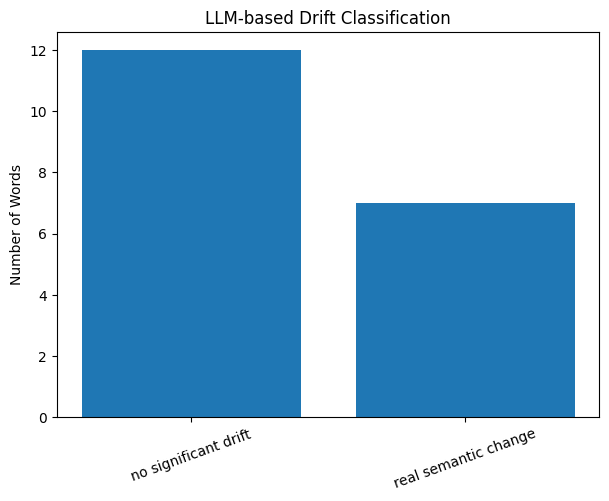

In [189]:
counts = final_df["drift_type"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(counts.index, counts.values)
plt.title("LLM-based Drift Classification")
plt.ylabel("Number of Words")
plt.xticks(rotation=20)
plt.show()

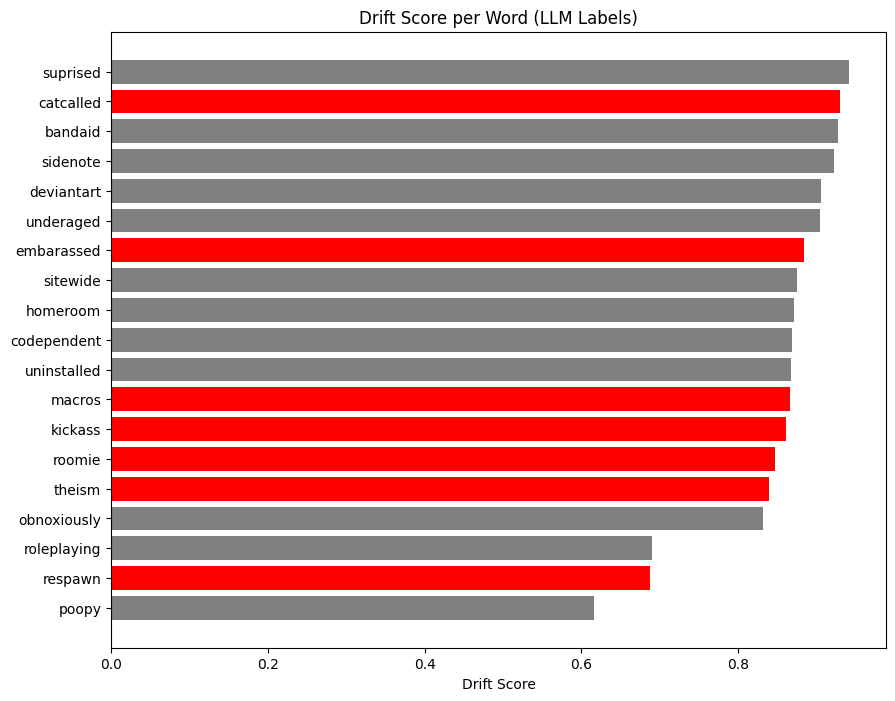

In [190]:
colors = final_df["drift_type"].map({
    "real semantic change": "red",
    "no significant drift": "gray"
})

plot_df = final_df.sort_values("drift_score")

plt.figure(figsize=(10,8))
plt.barh(plot_df["word"], plot_df["drift_score"], color=colors)
plt.xlabel("Drift Score")
plt.title("Drift Score per Word (LLM Labels)")
plt.show()

In [191]:
!pip install adjustText

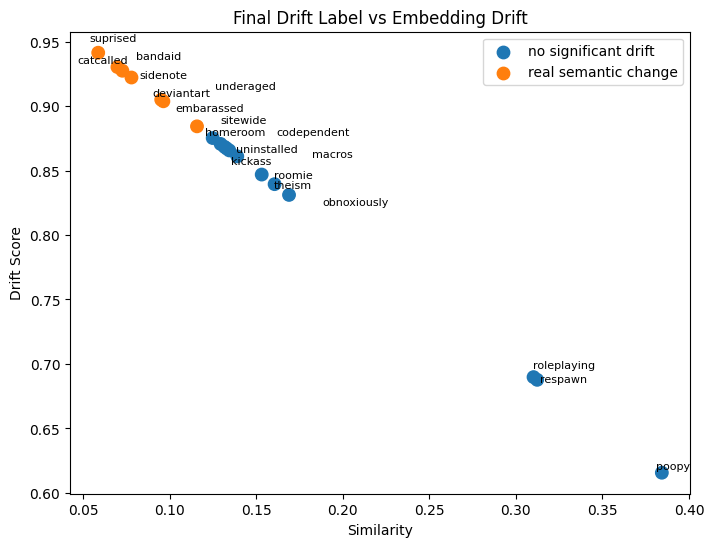

In [195]:
from adjustText import adjust_text
import matplotlib.pyplot as plt

# -----------------------------
# 1. PREP DATA
# -----------------------------
final_df = results_df.copy()
final_df["drift_type"] = final_df["final_label"]

# optional: if you later parse real confidence, replace this
final_df["confidence"] = "unknown"

# create confidence_score safely
final_df["confidence_score"] = final_df["confidence"].map({
    "High": 3,
    "Medium": 2,
    "Low": 1,
    "unknown": 1
}).fillna(1)

# -----------------------------
# 2. SCATTER PLOT (BEST VERSION)
# -----------------------------
plt.figure(figsize=(8,6))

texts = []

for label in final_df["drift_type"].unique():
    subset = final_df[final_df["drift_type"] == label]

    plt.scatter(
        subset["similarity"],
        subset["drift_score"],
        label=label,
        s=subset["confidence_score"] * 80  # safe now
    )

# add labels
for _, row in final_df.iterrows():
    texts.append(
        plt.text(
            row["similarity"],
            row["drift_score"],
            row["word"],
            fontsize=8
        )
    )

adjust_text(texts)

plt.xlabel("Similarity")
plt.ylabel("Drift Score")

# IMPORTANT: fix title (not LLM anymore)
plt.title("Final Drift Label vs Embedding Drift")

plt.legend()
plt.show()